# Biosynthetic pathway and the activation clusters

Do the co-tuning clusters of `02` line up with where the molecules come from biosynthetically?

Pathway labels are NPClassifier annotations taken from COCONUT and joined on InChIKey. Only
molecules COCONUT knows get one, so this runs on the natural-product subset.

Read the answer against two references, both computed below: a permutation floor, and the same
test on clusters built from bulk descriptors instead of receptor activation.

In [1]:
import sys, numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2_contingency
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Lipinski

sys.path.append("../../scripts")
from calibration import fit_calibration_map, density_fill
from plotting_functions import custom_plots, FIGSIZE
plt.rcParams.update(custom_plots())
np.random.seed(0)

PROB     = "../../predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
PAIRS    = "../../../Model/Data_Preparation/processed/m2or_pairs_model.csv"
FASTA    = "../../../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
ODORS    = "../../../Chemicals/odor_datasets/inchi_odors_smiles.csv"
PATHWAYS = "../../../Chemicals/odor_datasets/ligand_pathways.csv"
OUTDIR   = "Figures"
K        = 6
N_INIT   = 6000     # same as 02: the point at which PAM converges here

## 1 · Pathway annotations

`ligand_pathways.csv` is built from the COCONUT bulk CSV (`coconut_csv-*.zip` from
<https://coconut.naturalproducts.net/download>) joined on InChIKey. Rebuild it with
`build_pathways()` if the COCONUT dump is at hand; otherwise the committed file is read.

In [2]:
def build_pathways(coconut_csv, out=PATHWAYS):
    """Join the 754 ligands to COCONUT on InChIKey. Only needed to regenerate the file."""
    lig = pd.read_csv(ODORS)[["InChIKey", "SMILES"]]
    keys = set(lig["InChIKey"].dropna())
    cols = ["standard_inchi_key", "np_classifier_pathway",
            "np_classifier_superclass", "np_classifier_class", "name"]
    hits = [ch[ch["standard_inchi_key"].astype(str).isin(keys)]
            for ch in pd.read_csv(coconut_csv, usecols=cols, chunksize=200_000, low_memory=False)]
    coc = pd.concat(hits).drop_duplicates("standard_inchi_key").rename(columns={
        "standard_inchi_key": "InChIKey", "name": "coconut_name",
        "np_classifier_pathway": "pathway", "np_classifier_superclass": "superclass",
        "np_classifier_class": "npc_class"})
    frame = lig.merge(coc, on="InChIKey", how="left")
    frame["in_coconut"] = frame["pathway"].notna() | frame["coconut_name"].notna()
    frame.to_csv(out, index=False)
    return frame


paths = pd.read_csv(PATHWAYS)
print(f"ligands            : {len(paths)}")
print(f"  in COCONUT       : {int(paths.in_coconut.sum())}")
print(f"  with a pathway   : {int(paths.pathway.notna().sum())}")
print(f"  with a superclass: {int(paths.superclass.notna().sum())}")
print()
print(paths.pathway.value_counts().to_string())

ligands            : 754
  in COCONUT       : 536
  with a pathway   : 481
  with a superclass: 435

pathway
Fatty acids                        229
Terpenoids                          88
Shikimates and Phenylpropanoids     86
Alkaloids                           46
Amino acids and Peptides            15
Polyketides                         13
Carbohydrates                        4


## 2 · The activation matrix and its clusters

Same construction as `02`: density fill with the measured pairs overlaid, then Jaccard + PAM at
k = 6.

In [3]:
prob = pd.read_csv(PROB, index_col=0)
hum_pids = [i for i in prob.index if str(i).startswith("9606")]
P = prob.loc[hum_pids]; lig_cols = list(P.columns); Pv = P.values

pid2seq, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid: pid2seq[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else: buf.append(line)
if pid: pid2seq[pid] = "".join(buf).upper()
seq2pid = {}
for p in hum_pids: seq2pid.setdefault(pid2seq[p], []).append(p)

m = pd.read_csv(PAIRS, usecols=["Species","UniProt ID","Sequence","Responsive","smiles_id","mutation"])
hs = m[m["Species"].str.lower().str.contains("homo")].copy()
hs["Sequence"] = hs["Sequence"].str.upper().str.strip()
hs["pid"] = hs["Sequence"].map(lambda s: seq2pid.get(s, [None])[0])
exp = (hs[hs["pid"].notna() & hs["smiles_id"].isin(set(lig_cols))]
       .groupby(["pid","smiles_id"])["Responsive"].max().reset_index())

ridx = {p:i for i,p in enumerate(hum_pids)}; cidx = {c:j for j,c in enumerate(lig_cols)}
rr = np.array([ridx[p] for p in exp["pid"]]); cc = np.array([cidx[c] for c in exp["smiles_id"]])
y = exp["Responsive"].values.astype(int)
tested = np.zeros(Pv.shape, bool); tested[rr,cc] = True
E = np.zeros(Pv.shape, np.int8); E[rr,cc] = y
FILL = density_fill(Pv, fit_calibration_map(Pv[rr,cc], y), tested, E)
X = FILL.matrix.astype(int)
print(f"density {FILL.density:.4%}   cut {FILL.cut:.4f} (output)")


def kmedoids(D, k, n_init=N_INIT, seed=0):
    rng = np.random.default_rng(seed); n = len(D); best = None
    for _ in range(n_init):
        med = rng.choice(n, k, replace=False)
        for _ in range(300):
            lab = D[:, med].argmin(1); nm = med.copy()
            for c in range(k):
                idx = np.where(lab == c)[0]
                if len(idx): nm[c] = idx[D[np.ix_(idx, idx)].sum(1).argmin()]
            if set(nm) == set(med): med = nm; break
            med = nm
        lab = D[:, med].argmin(1); cost = D[np.arange(n), med[lab]].sum()
        if best is None or cost < best[0]: best = (cost, lab.copy())
    return best


cols = np.array(lig_cols); keep = X.sum(0) > 0
lig, Xn = cols[keep], X[:, keep]
Dj = np.nan_to_num(squareform(pdist(Xn.T, "jaccard")))
cost_rec, lab_rec = kmedoids(Dj, K)
print(f"receptor clusters  cost {cost_rec:.4f}  sizes {sorted(Counter(lab_rec).values(), reverse=True)}")

density 2.7453%   cut 0.8917 (output)


receptor clusters  cost 328.9871  sizes [214, 127, 108, 100, 70, 68]


## 3 · Pathway per cluster

`smiles_id` → SMILES → InChIKey → pathway. Molecules COCONUT does not know drop out, and so do
the two smallest pathway classes — with all seven the contingency table has too many near-empty
cells for chi-square to be valid.

In [4]:
pairs = pd.read_csv(PAIRS, usecols=["SMILES","smiles_id"])
sml2smiles = pairs.drop_duplicates("smiles_id").set_index("smiles_id")["SMILES"].to_dict()
smiles2key = dict(zip(pd.read_csv(ODORS)["SMILES"], pd.read_csv(ODORS)["InChIKey"]))
key2path = dict(zip(paths["InChIKey"], paths["pathway"]))

# Polyketides (n = 12) and Carbohydrates (n = 3) are dropped. Keeping all seven classes
# leaves 20 of 42 expected cells below 5, which breaks the chi-square validity assumption;
# on five classes it is 8 of 30. The restriction raises the receptor association rather
# than flattering it, so it is not a convenient choice.
PATHWAYS_KEPT = ["Fatty acids", "Shikimates and Phenylpropanoids", "Terpenoids",
                 "Alkaloids", "Amino acids and Peptides"]

pathway_all = np.array([key2path.get(smiles2key.get(sml2smiles.get(s)), None) for s in lig],
                       dtype=object)
pathway = np.array([p if p in PATHWAYS_KEPT else None for p in pathway_all], dtype=object)
has_path = pd.notna(pathway)

print(f"clustered ligands          : {len(lig)}")
print(f"  with any pathway         : {int(pd.notna(pathway_all).sum())}")
print(f"  in the {len(PATHWAYS_KEPT)} classes analysed : {int(has_path.sum())}")
for p in PATHWAYS_KEPT + ["Polyketides", "Carbohydrates"]:
    mark = "" if p in PATHWAYS_KEPT else "   [dropped, too few for chi-square]"
    print(f"    {p:34s} {int((pathway_all == p).sum()):3d}{mark}")


def cramers_v(labels, categories):
    ct = pd.crosstab(pd.Series(labels), pd.Series(categories))
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    return float(np.sqrt(chi2 / (n * (min(ct.shape) - 1)))), p, ct


def permutation_floor(labels, categories, reps=2000, seed=0):
    """Cramer V expected with no association. Not zero: finite n and skewed categories."""
    rng = np.random.default_rng(seed); labels = np.asarray(labels)
    v = [cramers_v(rng.permutation(labels), categories)[0] for _ in range(reps)]
    return float(np.mean(v)), float(np.percentile(v, 95))

clustered ligands          : 687
  with any pathway         : 442
  in the 5 classes analysed : 427
    Fatty acids                        205
    Shikimates and Phenylpropanoids     84
    Terpenoids                          81
    Alkaloids                           45
    Amino acids and Peptides            12
    Polyketides                         12   [dropped, too few for chi-square]
    Carbohydrates                        3   [dropped, too few for chi-square]


## 4 · The control: clusters from descriptors alone

In [5]:
DESC = {"MolWt": Descriptors.MolWt, "LogP": Crippen.MolLogP, "TPSA": rdMolDescriptors.CalcTPSA,
        "HBD": Lipinski.NumHDonors, "HBA": Lipinski.NumHAcceptors,
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings,
        "RotBonds": Descriptors.NumRotatableBonds, "RingCount": rdMolDescriptors.CalcNumRings,
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3, "Heteroatoms": Lipinski.NumHeteroatoms}

rows = []
for s in lig:
    mol = Chem.MolFromSmiles(sml2smiles.get(s) or "")
    rows.append([DESC[k](mol) if mol else np.nan for k in DESC])
desc = pd.DataFrame(rows, columns=list(DESC), index=lig)

ok = desc.notna().all(1).values
Z = ((desc - desc.mean()) / desc.std()).values
cost_d, lab_sub = kmedoids(squareform(pdist(Z[ok], "euclidean")), K)
lab_desc = np.full(len(lig), -1); lab_desc[np.where(ok)[0]] = lab_sub
print(f"descriptor clusters  sizes {sorted(Counter(lab_sub).values(), reverse=True)}")

descriptor clusters  sizes [190, 130, 117, 115, 102, 33]


## 5 · The comparison

The receptor clusters against the descriptor clusters, both on the same molecules.

In [6]:
use = has_path & (lab_desc >= 0)
print(f"molecules compared: {int(use.sum())}\n")

results = {}
for name, labels in [("receptor clusters", lab_rec), ("descriptor clusters", lab_desc)]:
    v, p, ct = cramers_v(labels[use], pathway[use])
    mu, hi = permutation_floor(labels[use], pathway[use])
    results[name] = dict(v=v, p=p, floor=mu, floor95=hi, ct=ct)
    print(f"{name:20s} Cramer V = {v:.3f}   chi2 p = {p:.3g}"
          f"   floor {mu:.3f} (95th {hi:.3f})")

print("\nreceptor cluster x pathway")
print(results["receptor clusters"]["ct"].to_string())

molecules compared: 427



receptor clusters    Cramer V = 0.356   chi2 p = 6.28e-35   floor 0.107 (95th 0.137)


descriptor clusters  Cramer V = 0.569   chi2 p = 2e-104   floor 0.108 (95th 0.138)

receptor cluster x pathway
col_0  Alkaloids  Amino acids and Peptides  Fatty acids  Shikimates and Phenylpropanoids  Terpenoids
row_0                                                                                               
0              6                         2           16                               22          28
1              1                         0          100                                6          21
2              1                         7           19                                5          12
3              9                         0           35                               14          10
4             22                         1            6                               34           6
5              6                         2           29                                3           4


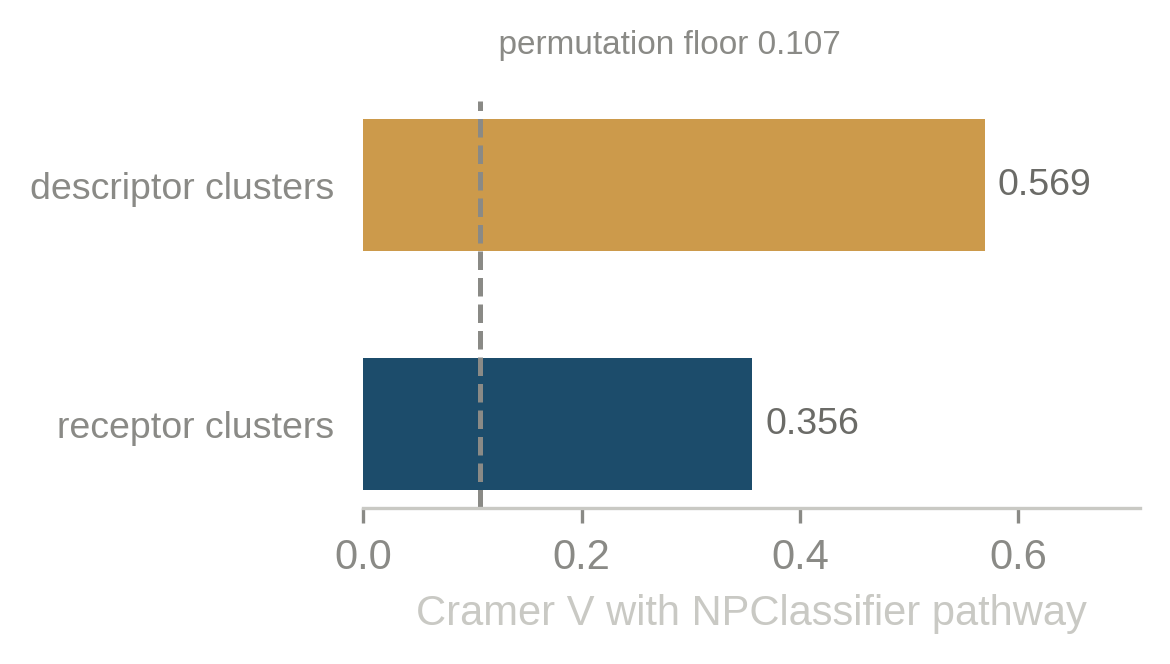

In [7]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0], FIGSIZE[1] * 0.8))
names = list(results)
vals = [results[n]["v"] for n in names]
flo = results[names[0]]["floor"]
ax.barh(range(len(names)), vals, color=["#083d5e", "#C8923B"], height=0.55, alpha=0.92)
ax.axvline(flo, ls="--", lw=1.2, color="#8a8a86")
ax.text(flo, len(names) - 0.35, f"  permutation floor {flo:.3f}",
        fontsize=8, color="#8a8a86", va="top")
for i, v in enumerate(vals):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9, color="#6b6b67")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlim(0, max(vals) * 1.25); ax.set_xlabel("Cramer V with NPClassifier pathway", fontsize=10)
for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout(); plt.savefig(f"{OUTDIR}/05_pathway_recovery.svg", bbox_inches="tight"); plt.show()

pd.DataFrame([{"clustering": n, "cramers_v": results[n]["v"], "chi2_p": results[n]["p"],
               "floor": results[n]["floor"], "floor_95th": results[n]["floor95"],
               "n": int(use.sum())} for n in names]).to_csv(
    f"{OUTDIR}/05_pathway_recovery.csv", index=False)

## 6 · Naming the clusters

Same odour enrichment as `02`, so the pathway figures can be read against a cluster's
perceptual identity rather than its index.

In [8]:
from scipy.stats import hypergeom

odo = pd.read_csv(ODORS)
smiles2tags = {s: [t.strip().lower() for t in o.split(",") if t.strip()]
               for s, o in zip(odo["SMILES"], odo["Odors"]) if isinstance(o, str) and o.strip()}
sml2tags = {sid: smiles2tags[sml2smiles[sid]] for sid in lig if sml2smiles.get(sid) in smiles2tags}


def bh(p):
    p = np.asarray(p); m = len(p); o = np.argsort(p); r = p[o]
    q = np.minimum.accumulate((r * m / (np.arange(m) + 1))[::-1])[::-1]
    out = np.empty(m); out[o] = np.clip(q, 0, 1); return out


def cluster_names(labels, k=K, top=3):
    tagged = np.array([s in sml2tags for s in lig])
    tagN = Counter([t for s in lig[tagged] for t in sml2tags[s]]); N = int(tagged.sum())
    tags = [t for t, c in tagN.items() if c >= 5]
    rows = []
    for c in range(k):
        mem = [s for s in lig[labels == c] if s in sml2tags]; n = len(mem)
        ct = Counter([t for s in mem for t in sml2tags[s]])
        for t in tags:
            kk = ct.get(t, 0); Kt = tagN[t]; e = n * Kt / N
            rows.append([c, t, kk / e if e else 0, hypergeom.sf(kk - 1, N, Kt, n) if kk else 1.0])
    enr = pd.DataFrame(rows, columns=["cluster", "tag", "obs_exp", "p"])
    enr["fdr"] = bh(enr["p"].values)
    sig = enr[(enr.fdr < 0.05) & (enr.obs_exp > 1)]
    out = {}
    for c in range(k):
        s = sig[sig.cluster == c].sort_values("obs_exp", ascending=False).tag.head(top).tolist()
        out[c] = " / ".join(s) if s else "unnamed"
    return out


REC_NAMES = cluster_names(lab_rec)
for c, nm in REC_NAMES.items():
    print(f"  cluster {c}  n={int((lab_rec == c).sum()):3d}   {nm}")

  cluster 0  n=127   floral
  cluster 1  n=214   cucumber / coconut / melon
  cluster 2  n= 70   acidic / sour / cheesy
  cluster 3  n=108   smoky / medicinal / phenolic
  cluster 4  n=100   hazelnut / warm / anisic
  cluster 5  n= 68   solvent / alcoholic / ethereal


## 7 · Where the pathways sit

Left: what each cluster is made of. Right: which cells carry the association — Pearson
residuals, so red is more molecules than independence predicts and blue is fewer.

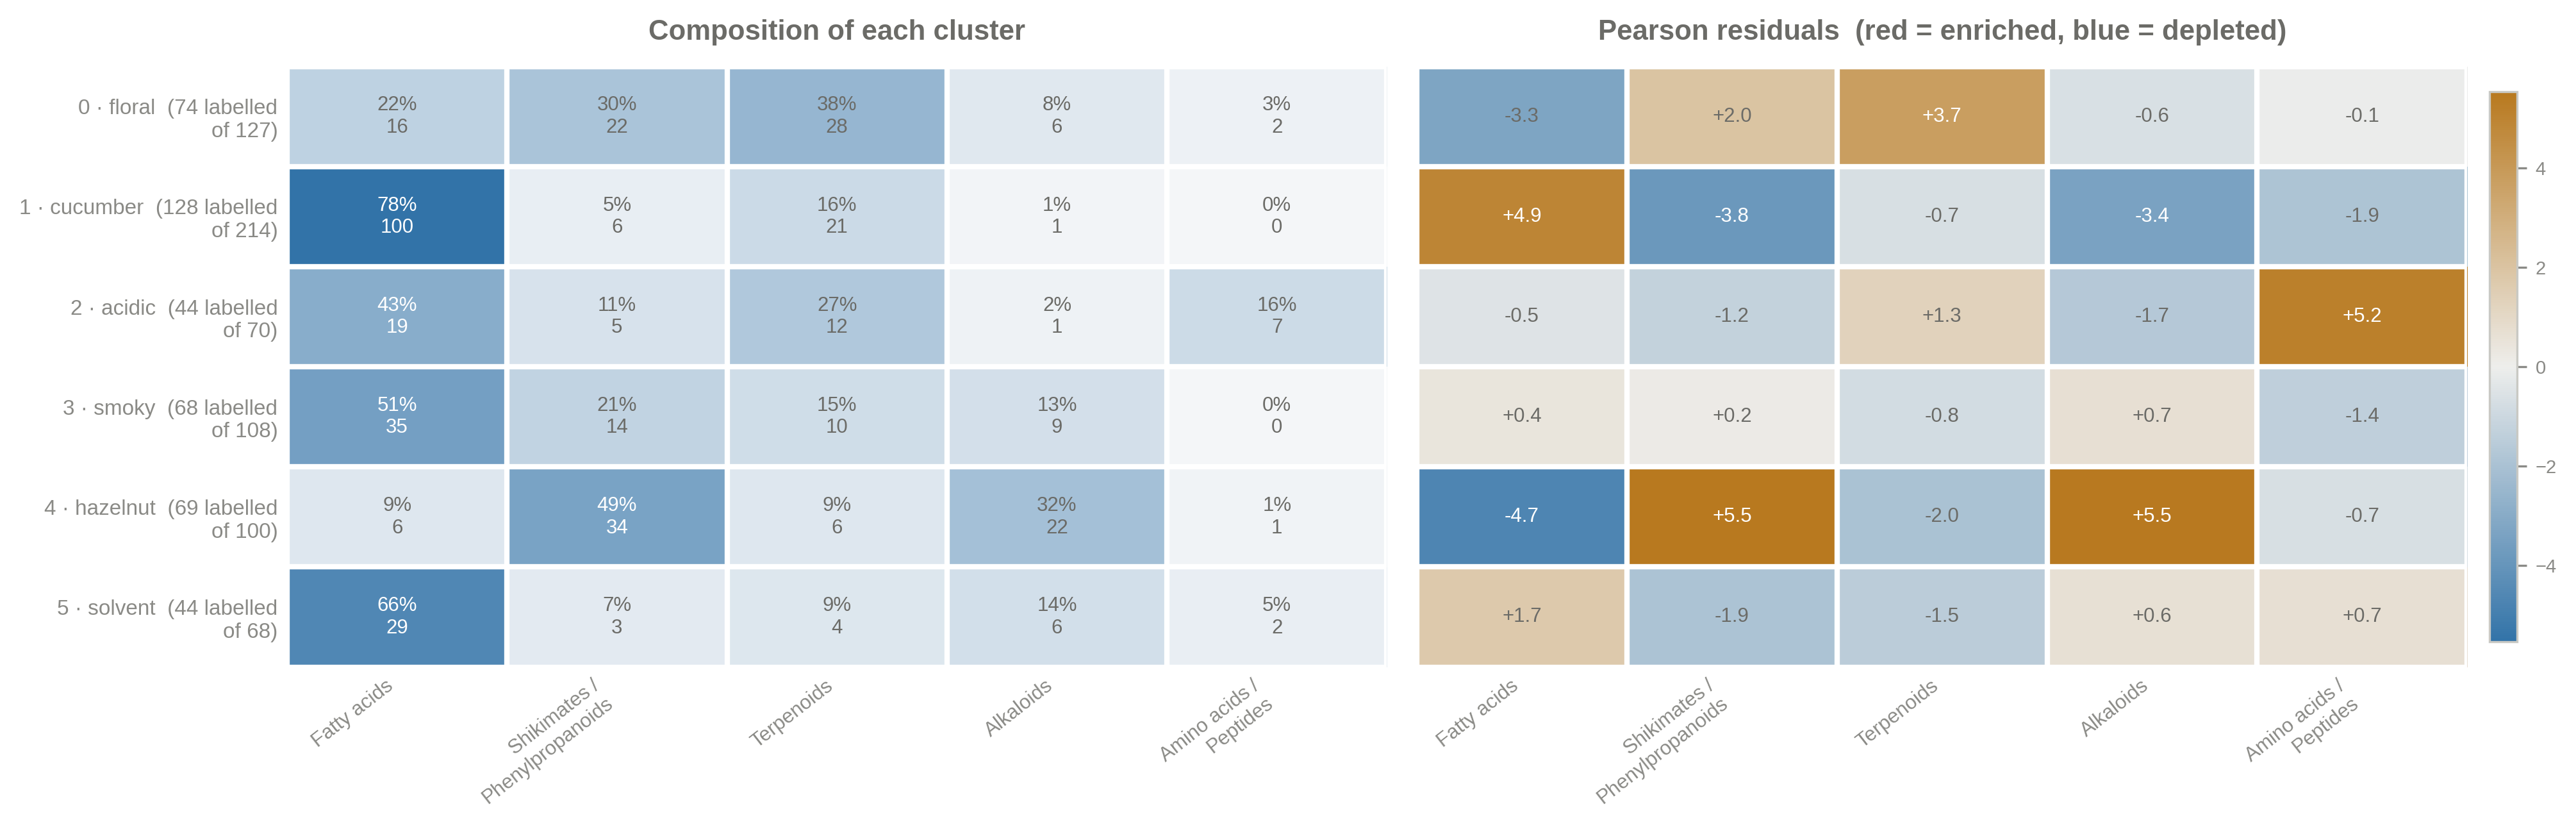

In [9]:
SEQ_HUE  = "#3273a8"     # validated sequential hue
POS, NEG = "#b8791f", "#3273a8"
INK, MUTED = "#6b6b67", "#8a8a86"

ct_rec = results["receptor clusters"]["ct"]
order = ct_rec.sum(0).sort_values(ascending=False).index      # pathways, commonest first
ct_rec = ct_rec[order]
comp = ct_rec.div(ct_rec.sum(1), axis=0) * 100
chi2, _, _, expected = chi2_contingency(ct_rec)
resid = (ct_rec.values - expected) / np.sqrt(expected)

ylab = [f"{c} · {REC_NAMES[c].split(' / ')[0]}  ({int(ct_rec.iloc[c].sum())} labelled\nof {int((lab_rec == c).sum())})" for c in ct_rec.index]
xlab = [p.replace("Shikimates and Phenylpropanoids", "Shikimates /\nPhenylpropanoids")
         .replace("Amino acids and Peptides", "Amino acids /\nPeptides") for p in order]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

cmap_seq = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#f4f6f8", SEQ_HUE])
ax = axes[0]
ax.imshow(comp.values, cmap=cmap_seq, aspect="auto", vmin=0, vmax=comp.values.max())
for i in range(comp.shape[0]):
    for j in range(comp.shape[1]):
        v = comp.values[i, j]
        ax.text(j, i, f"{v:.0f}%\n{int(ct_rec.values[i, j])}", ha="center", va="center",
                fontsize=7.5, color="white" if v > comp.values.max() * 0.55 else INK)
ax.set_title("Composition of each cluster", fontsize=10.5, fontweight="bold", color=INK, pad=10)

lim = np.abs(resid).max()
cmap_div = mpl.colors.LinearSegmentedColormap.from_list("div", [NEG, "#eeeeec", POS])
ax = axes[1]
im = ax.imshow(resid, cmap=cmap_div, aspect="auto", vmin=-lim, vmax=lim)
for i in range(resid.shape[0]):
    for j in range(resid.shape[1]):
        ax.text(j, i, f"{resid[i, j]:+.1f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(resid[i, j]) > lim * 0.6 else INK)
ax.set_title("Pearson residuals  (red = enriched, blue = depleted)",
             fontsize=10.5, fontweight="bold", color=INK, pad=10)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02).ax.tick_params(labelsize=7)

for k_, ax in enumerate(axes):
    ax.set_xticks(range(len(xlab)))
    ax.set_xticklabels(xlab, fontsize=7.5, rotation=38, ha="right", color=MUTED)
    ax.set_yticks(range(len(ylab)))
    ax.set_yticklabels(ylab if k_ == 0 else [], fontsize=8, color=MUTED)
    ax.set_xticks(np.arange(-.5, len(xlab), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(ylab), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0); ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout(); plt.savefig(f"{OUTDIR}/05_pathway_by_cluster.svg", bbox_inches="tight"); plt.show()

## 8 · Against the null, and against descriptors

The permutation floor is not zero — six clusters over seven skewed categories at this n will
show association by chance alone. Both observed values sit far outside it; the question is how
they sit relative to each other.

The right panel is descriptive, not an enrichment: a pathway can look gathered simply by landing in a big cluster. The residuals in the previous figure are the size-corrected view.

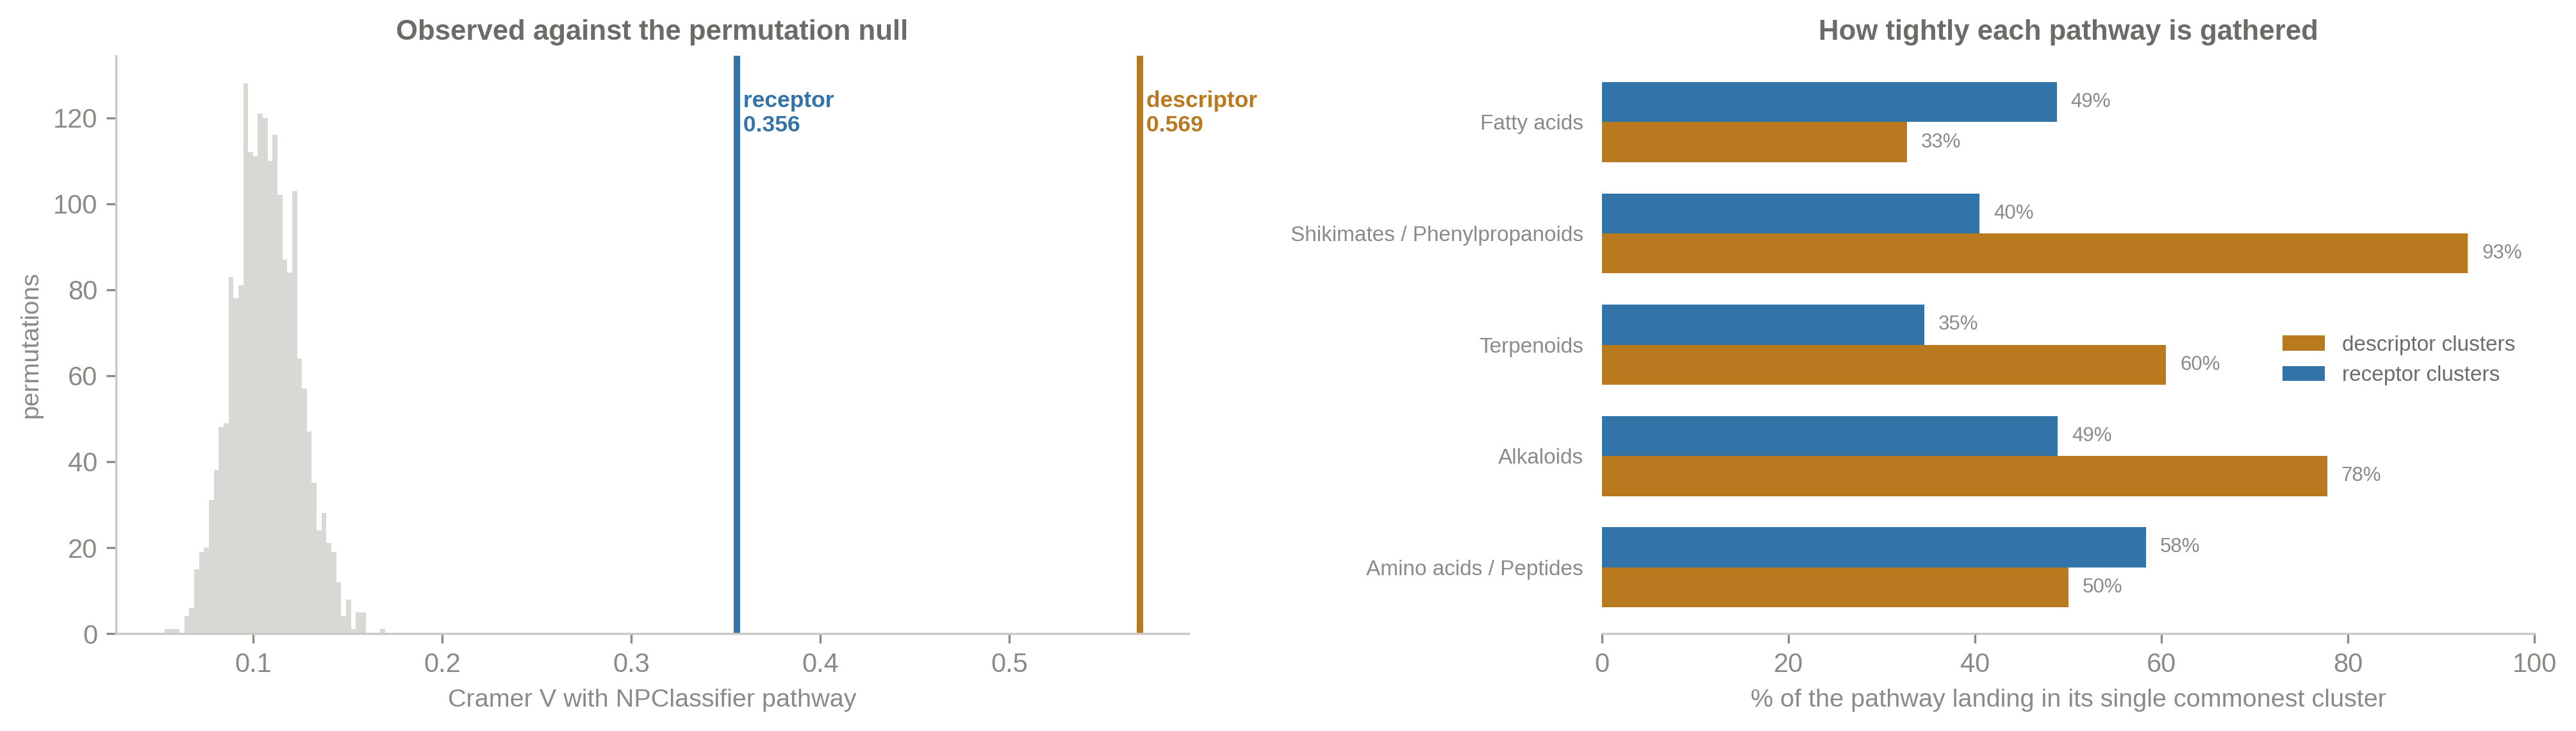

concentration in the commonest cluster (%)
  Fatty acids                        receptor  48.8   descriptor  32.7
  Shikimates and Phenylpropanoids    receptor  40.5   descriptor  92.9
  Terpenoids                         receptor  34.6   descriptor  60.5
  Alkaloids                          receptor  48.9   descriptor  77.8
  Amino acids and Peptides           receptor  58.3   descriptor  50.0


In [10]:
rng = np.random.default_rng(0)
null = {}
for name, labels in [("receptor clusters", lab_rec), ("descriptor clusters", lab_desc)]:
    lv = np.asarray(labels)[use]; cv = pathway[use]
    null[name] = np.array([cramers_v(rng.permutation(lv), cv)[0] for _ in range(2000)])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.9),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.hist(null["receptor clusters"], bins=45, color="#d8d8d4", edgecolor="none", label="null (permuted)")
for name, col in [("receptor clusters", NEG), ("descriptor clusters", POS)]:
    v = results[name]["v"]
    ax.axvline(v, color=col, lw=2.4)
    ax.text(v, ax.get_ylim()[1] * 0.94, f" {name.split()[0]}\n {v:.3f}",
            fontsize=8.5, color=col, va="top", fontweight="bold")
ax.set_xlabel("Cramer V with NPClassifier pathway", fontsize=9.5, color=MUTED)
ax.set_ylabel("permutations", fontsize=9.5, color=MUTED)
ax.set_title("Observed against the permutation null", fontsize=10.5, fontweight="bold", color=INK)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

# per-pathway concentration: share of a pathway's molecules in its single commonest cluster
def concentration(labels):
    out = {}
    for p in order:
        sel = (pathway == p) & use
        if sel.sum() < 5: continue
        out[p] = Counter(np.asarray(labels)[sel]).most_common(1)[0][1] / sel.sum() * 100
    return out

cr, cd = concentration(lab_rec), concentration(lab_desc)
ps = list(cr); yy = np.arange(len(ps)); h = 0.36
ax = axes[1]
ax.barh(yy + h/2, [cd[p] for p in ps], height=h, color=POS, label="descriptor clusters")
ax.barh(yy - h/2, [cr[p] for p in ps], height=h, color=NEG, label="receptor clusters")
for i, p in enumerate(ps):
    ax.text(cd[p] + 1.5, i + h/2, f"{cd[p]:.0f}%", va="center", fontsize=7.5, color=MUTED)
    ax.text(cr[p] + 1.5, i - h/2, f"{cr[p]:.0f}%", va="center", fontsize=7.5, color=MUTED)
ax.set_yticks(yy); ax.set_yticklabels([p.replace(" and ", " / ") for p in ps], fontsize=8, color=MUTED)
ax.set_xlabel("% of the pathway landing in its single commonest cluster", fontsize=9.5, color=MUTED)
ax.set_xlim(0, 100); ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 0.55), labelcolor=INK)
ax.set_title("How tightly each pathway is gathered", fontsize=10.5, fontweight="bold", color=INK)
for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout(); plt.savefig(f"{OUTDIR}/05_pathway_null_and_concentration.svg", bbox_inches="tight"); plt.show()

print("concentration in the commonest cluster (%)")
for p in ps:
    print(f"  {p:34s} receptor {cr[p]:5.1f}   descriptor {cd[p]:5.1f}")

## What this shows

**Both clusterings clear the null; descriptors clear it further.** Against a permutation floor of
0.107 (95th percentile 0.137), receptor clusters reach V = 0.356 and descriptor clusters 0.569,
on the 427 molecules carrying one of the five analysed pathways. The activation clusters do carry
biosynthetic signal — but less of it than the molecules' descriptors carry on their own.

**That ordering is the result, and it points the way it should.** Biosynthetic pathway is a fact
about how a molecule was assembled; it fixes the scaffold and the functional groups. RDKit
descriptors measure those directly. The receptor code is the same chemistry projected through 433
receptors, each a coarse and partly redundant filter — a projection that can only discard
structural information, never add it. Descriptors beating receptors is therefore the expected
outcome. The reverse would have implied the repertoire encodes something about synthesis history
beyond structure, which receptors have no mechanism to do: they bind shapes, not provenance. This
is a consistency check that passes, not a discovery.

Note also that the descriptor clusters are *built from* the same descriptors that drive pathway
assignment, so 0.569 is better read as a ceiling on what any structure-derived partition could
reach than as a rival method.

**Three clusters carry the association.** From the residuals: cluster 1 (cucumber / coconut /
melon) is fatty acids, +4.9, and depleted of shikimates and alkaloids; cluster 4 (hazelnut / warm
/ anisic) is the mirror image — alkaloids +5.5, shikimates +5.5, fatty acids −4.7; cluster 2
(acidic / sour / cheesy) holds the amino acids and peptides, +5.2; cluster 0 (floral) is
terpenoid-leaning, +3.7. Cluster 3 (smoky) contributes essentially nothing. That is the ordinary
flavour-chemistry correspondence appearing without having been put in, which is the useful part:
the clusters are chemically real.

**One place the receptor view adds something.** Fatty acids are gathered better by receptor
clusters than by descriptors (49% vs 33%), and so are amino acids and peptides (58% vs 50%).
Everywhere else descriptors dominate — shikimates 93% vs 40%, alkaloids 78% vs 49%, terpenoids
60% vs 35%. Fatty acids span a wide range of chain lengths, so descriptors scatter them across
clusters while perception keeps them together. That is the one axis on which the receptor code is
the more informative representation.

## Limits

- Of 687 clustered ligands, 442 carry any pathway and 427 fall in the five classes analysed.
  COCONUT holds natural products, so this runs on the natural-product subset rather than the full
  panel, and annotated molecules are the better-studied ones.
- **Polyketides (12) and Carbohydrates (3) are excluded.** With all seven classes, 20 of 42
  expected cells fall below 5 and chi-square is not valid; on five classes it is 8 of 30.
- NPClassifier infers pathway from structure, and the activation profiles are predicted from
  structure, so part of any association is two structure-derived labels agreeing.
- The pathway mix is skewed — fatty acids are 205 of the 427 analysed.
- Pathways were joined on the full InChIKey against the COCONUT 2026-08 release. Pathway
  assignments change between releases, so the release month belongs in Methods. 202 further
  ligands match only at the skeleton level, where COCONUT holds a different stereoisomer; those
  were left out.

**The claim to make:** the activation clusters are chemically coherent enough to recover
biosynthetic origin. Not that the receptor code carries biosynthetic information beyond chemistry.
